<a href="https://colab.research.google.com/github/Viishnu07/DLI_GroupAE_URLPhishing/blob/main/Venus_Ong_Jin_Wen_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install dependencies
!pip install keras tensorflow --quiet
!pip install wget --quiet
!pip install tabulate --quiet
import os
import numpy as np
import string
import urllib.request
import wget
import time
import seaborn as sns
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tabulate import tabulate
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

# Set random seed for reproducibility
np.random.seed(42)

  Preparing metadata (setup.py) ... done


# **Download and Load Dataset**

*   Create a local folder dataset/ to store downloaded files.
*   Use urllib to programmatically download the train.txt, val.txt, and test.txt files from the GitHub repository.
*   Each dataset file contains URLs labeled as either phishing or legitimate, separated by a tab (\t).
*   Define a function load_dataset() to:
    * Parse each line into <label> <url> format.
    * Convert labels to binary (1 for phishing, 0 for legitimate).
    * Return two lists: urls and labels.
* Load and prepare all three datasets: train, validation, and test.











In [2]:
# Step 1: Create folder
os.makedirs("dataset", exist_ok=True)
# Step 2: GitHub raw URLs
dataset_urls = {
    "train.txt": "https://media.githubusercontent.com/media/Viishnu07/DLI_GroupAE_URLPhishing/main/dataset/train.txt",
    "val.txt": "https://media.githubusercontent.com/media/Viishnu07/DLI_GroupAE_URLPhishing/main/dataset/val.txt",
    "test.txt": "https://media.githubusercontent.com/media/Viishnu07/DLI_GroupAE_URLPhishing/main/dataset/test.txt" }

# Step 3: Download each file
for filename, url in dataset_urls.items():
  print(f"Downloading {filename}...")
  urllib.request.urlretrieve(url, f"dataset/{filename}")
print("All files downloaded.")

# Load dataset (each line: "<label> <url>")
def load_dataset(file_path):
  urls, labels = [], []
  with open(file_path, 'r') as f:
    for line in f:
      parts = line.strip().split('\t') # Ensure it's tab-separated
      if len(parts) == 2:
        label_str, url = parts
        label = 1 if label_str.lower() == 'phishing' else 0
        urls.append(url)
        labels.append(label)
  return urls, labels

# Load using the downloaded files
train_urls, train_labels = load_dataset("dataset/train.txt")
val_urls, val_labels = load_dataset("dataset/val.txt")
test_urls, test_labels = load_dataset("dataset/test.txt")

All files downloaded.


# **Character Mapping and URL Vectorization**

*   Define a character vocabulary using all printable ASCII characters (string.printable), and assign each character a unique index.
*   Reserve index 0 for padding and calculate the total vocab_size.
*   Set the maximum URL length (MAX_LEN) to 200 characters to standardize input length.
*   Implement two functions:
   * url_to_sequence(): Converts a URL into a list of character indices (up to MAX_LEN).
   * vectorize_urls(): Applies url_to_sequence() to a list of URLs and pads the sequences to uniform length.
*  Vectorize the train, validation, and test URLs into numeric sequences using the mapping.
*  One-hot encode the labels into categorical format (2 classes: phishing, legitimate).
*  Print the final shape of each dataset to verify successful preprocessing.


In [3]:
# Char mapping
CHARS = string.printable
char2idx = {c: i + 1 for i, c in enumerate(CHARS)}  # 0 = padding
vocab_size = len(char2idx) + 1
MAX_LEN = 200

# Vectorization
def url_to_sequence(url):
    return [char2idx.get(c, 0) for c in url[:MAX_LEN]]

def vectorize_urls(urls):
    sequences = [url_to_sequence(url) for url in urls]
    return pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

X_train = vectorize_urls(train_urls)
X_val = vectorize_urls(val_urls)
X_test = vectorize_urls(test_urls)

y_train = to_categorical(train_labels, num_classes=2)
y_val = to_categorical(val_labels, num_classes=2)
y_test = to_categorical(test_labels, num_classes=2)

# Shape check
print(" All datasets loaded and vectorized:")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Vocab size:    {vocab_size}")

 All datasets loaded and vectorized:
X_train shape: (3641984, 200)
X_val shape:   (1045772, 200)
X_test shape:  (515080, 200)
y_train shape: (3641984, 2)
Vocab size:    101


# **CNN Model Definition, Training & Inference**
* Split the training data in half to reduce memory load:
  * X_train_1: First 1.8M samples
  * X_train_2: Remaining samples (≈1.8M)
* Define the CNN1+ architecture:
  * Embedding layer for character-level tokenization
  * 3 stacked Conv1D layers (256 → 128 → 64 filters), with batch normalization and pooling
  * Fully connected (Dense) layer with dropout
  * Final softmax layer for binary classification
* Compile the model using:
  * Adam optimizer (lr=0.001)
  * Categorical crossentropy loss
  * Accuracy metric
  * Callbacks: EarlyStopping and ReduceLROnPlateau to prevent overfitting
* Count parameters for analysis and slides, and print the model summary
* Train the model in 2 stages:
  * Stage 1: Train on X_train_1
  * Stage 2: Fine-tune on X_train_2
* Evaluate model performance on the test set and compute predictions
* Benchmark inference speed:
  * Run warmup + timed inferences on batches of 2048
  * Report URLs per second processed (useful for real-time deployment considerations)


In [4]:
# ----------------------------
# STEP 1: Split Training Dataset
# ----------------------------
X_train_1 = X_train[:1800000]
y_train_1 = y_train[:1800000]

X_train_2 = X_train[1800000:]
y_train_2 = y_train[1800000:]

# ----------------------------
# STEP 2: CNN1+ Model Definition
# ----------------------------
def build_cnn1_plus(vocab_size, max_len=200):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=50))

    model.add(Conv1D(filters=256, kernel_size=3, activation='relu'))
    model.add(BatchNormalization())

    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))

    model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(2, activation='softmax'))

    return model

# ----------------------------
# STEP 3: Compile Model
# ----------------------------
model = build_cnn1_plus(vocab_size)

optimizer = Adam(learning_rate=0.001)

callbacks = [
    EarlyStopping(patience=2, restore_best_weights=True),
    ReduceLROnPlateau(patience=1, factor=0.5, min_lr=1e-5)
]

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
# ----------------------------
# STEP 3b: Build once + count params (for slides)
# ----------------------------
# Force-build with known input shape so params are instantiated
model.build((None, MAX_LEN))

print("Total params:", model.count_params())
print("Trainable params:", np.sum([np.prod(v.shape) for v in model.trainable_weights]))
print("Non-trainable params:", np.sum([np.prod(v.shape) for v in model.non_trainable_weights]))

# (Optional) Layer-wise breakdown for your appendix
model.summary()

# ----------------------------
# STEP 4: Train on First Half
# ----------------------------
history1 = model.fit(
    X_train_1, y_train_1,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=1024,
    callbacks=callbacks,
    verbose=1
)

# ----------------------------
# STEP 5: Fine-Tune on Second Half
# ----------------------------
history2 = model.fit(
    X_train_2, y_train_2,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=1024,
    callbacks=callbacks,
    verbose=1
)

# ----------------------------
# STEP 6: Evaluate on Test Set
# ----------------------------
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# ----------------------------
# STEP 6b: Inference Benchmark
# ----------------------------

def benchmark_inference(m, x, warmup=3, iters=10, batch_size=2048):
    # Warmup runs (to load graph & avoid first-run overhead)
    for _ in range(warmup):
        _ = m.predict(x[:batch_size], batch_size=batch_size, verbose=0)
    # Timed runs
    start = time.time()
    seen = 0
    for _ in range(iters):
        _ = m.predict(x[:batch_size], batch_size=batch_size, verbose=0)
        seen += min(batch_size, x.shape[0])
    dur = time.time() - start
    return seen / dur, dur, seen  # urls_per_sec, total_seconds, total_urls

urls_per_sec, seconds, total = benchmark_inference(model, X_test)
print(f"Inference throughput: {urls_per_sec:,.0f} URLs/s "
      f"(processed {total:,} URLs in {seconds:.2f}s, batch=2048)")

Total params: 955004
Trainable params: 954492
Non-trainable params: 512


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 50)        │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 198, 256)       │        38,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 198, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 196, 128)       │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 98, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 96, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 955,004 (3.64 MB)

 Trainable params: 954,492 (3.64 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 190s 102ms/step - accuracy: 0.9464 - loss: 0.1278 - val_accuracy: 0.9801 - val_loss: 0.0523 - learning_rate: 0.0010
Epoch 2/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 183s 96ms/step - accuracy: 0.9837 - loss: 0.0428 - val_accuracy: 0.9847 - val_loss: 0.0406 - learning_rate: 0.0010
Epoch 3/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 171s 97ms/step - accuracy: 0.9867 - loss: 0.0353 - val_accuracy: 0.9863 - val_loss: 0.0362 - learning_rate: 0.0010
Epoch 4/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 202s 97ms/step - accuracy: 0.9886 - loss: 0.0303 - val_accuracy: 0.9873 - val_loss: 0.0340 - learning_rate: 0.0010
Epoch 5/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 200s 96ms/step - accuracy: 0.9898 - loss: 0.0273 - val_accuracy: 0.9879 - val_loss: 0.0335 - learning_rate: 0.0010
Epoch 6/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 201s 96ms/step - accuracy: 0.9909 - loss: 0.0244 - val_accuracy: 0.9886 - val_loss: 0.0314 - learning_rate: 0.0010
Epoch 7/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 170s 97ms/step 

# **Evaluation Metrics, System Performance & Visualization**

* Generate a tabulated classification report:
  * Includes precision, recall, f1-score, and support for each class
  * Uses tabulate() to render the output in a clean table-style grid
* Compute system metrics for performance evaluation:
  * Total, trainable, and non-trainable parameter counts
  * Inference throughput using a benchmark function (URLs/sec)
  * Total runtime and processed URLs
  * ROC AUC score as a single summary metric for binary classification
* Visualize results:
  * Confusion matrix with Seaborn heatmap to observe correct vs incorrect predictions
  * ROC curve plotted to show the trade-off between TPR and FPR with AUC annotation
These evaluation steps ensure that the model is not only accurate but also efficient and deployment-ready.

Classification Report:

+--------------+-------------+----------+------------+------------+
|              |   precision |   recall |   f1-score |    support |
+==============+=============+==========+============+============+
| Legitimate   |      0.9913 |   0.9943 |     0.9928 | 285314     |
+--------------+-------------+----------+------------+------------+
| Phishing     |      0.9929 |   0.9891 |     0.991  | 229766     |
+--------------+-------------+----------+------------+------------+
| accuracy     |      0.992  |   0.992  |     0.992  |      0.992 |
+--------------+-------------+----------+------------+------------+
| macro avg    |      0.9921 |   0.9917 |     0.9919 | 515080     |
+--------------+-------------+----------+------------+------------+
| weighted avg |      0.992  |   0.992  |     0.992  | 515080     |
+--------------+-------------+----------+------------+------------+

System Metrics:

+----+----------------------+---------------+
|    | Metric               

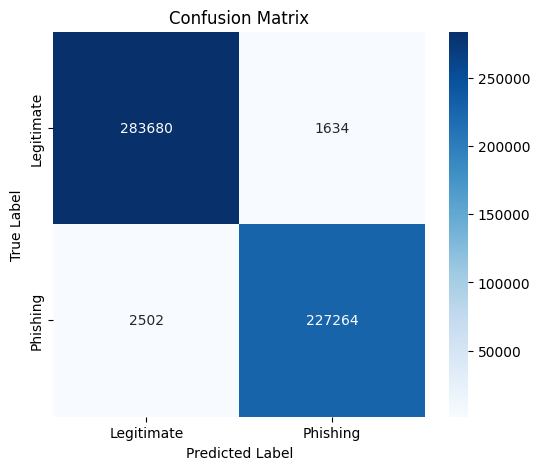

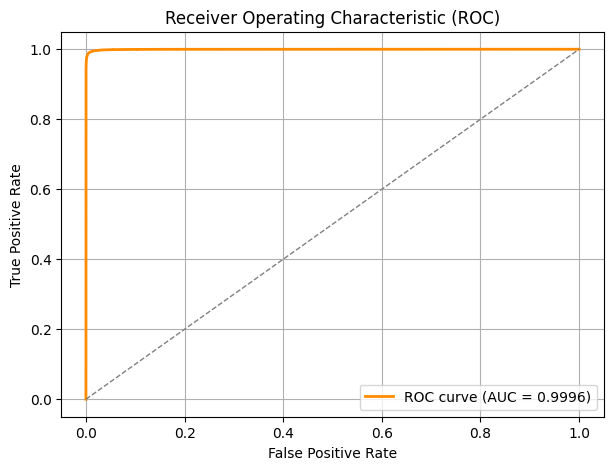

In [7]:
# ----------------------------
# STEP 7: Classification Report
# ----------------------------
report = classification_report(y_true, y_pred,
                               target_names=['Legitimate', 'Phishing'],
                               output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report = df_report[['precision', 'recall', 'f1-score', 'support']].round(4)

print("Classification Report:\n")
print(tabulate(df_report, headers='keys', tablefmt='grid'))

# ----------------------------
# EXTRA: System Metrics (Params + Inference + AUC)
# ----------------------------
# Params
total_params = model.count_params()
trainable_params = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
non_trainable_params = int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights]))

# Inference (uses your benchmark_inference function)
urls_per_sec, seconds, total = benchmark_inference(model, X_test)

# AUC for the summary table (you already plot later; we compute here too)
y_scores = y_pred_probs[:, 1]
auc_val = roc_auc_score(y_true, y_scores)

sys_rows = [
    ["Total Params",        f"{total_params:,}"],
    ["Trainable Params",    f"{trainable_params:,}"],
    ["Non-trainable Params",f"{non_trainable_params:,}"],
    ["Inference Throughput",f"{int(urls_per_sec):,} URLs/s"],
    ["Benchmark Runtime",   f"{seconds:.2f} s"],
    ["URLs Processed",      f"{total:,}"],
    ["ROC AUC",             f"{auc_val:.4f}"],
]
df_sys = pd.DataFrame(sys_rows, columns=["Metric", "Value"])

print("\nSystem Metrics:\n")
print(tabulate(df_sys, headers='keys', tablefmt='grid'))

# ----------------------------
# STEP 8: Confusion Matrix
# ----------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# ----------------------------
# STEP 9: ROC Curve
# ----------------------------
y_scores = y_pred_probs[:, 1]  # probability of class 1 (phishing)
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = roc_auc_score(y_true, y_scores)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# **Save & Download Trained Model**

* Save the fully trained model in Keras format (.keras) using model.save()
* Download the model locally to computer using files.download() from Google Colab

In [8]:
from keras.saving import save_model

# Save to local Colab file system
model.save("Venus_CNN.keras")

from google.colab import files

# Download to your computer
files.download("Venus_CNN.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>